# Trabajo Semanal 4 <img src="fig/logo_utn_encabezado.png" width="250" align="right"/>
## por Julián Galeano Pinazo
### Teoría de los Circuitos II - Docentes: Mariano Llamedo Soria y David Moharos


#### Dada la siguiente plantilla de diseño:

<img src="fig/plantilla.png" style="float: left; margin-right: 10px;" width="600"/>


#### 1. Obtener la función transferencia $T(s)$ de Bessel para $N:2,3\;\text{y}\;4$ normalizados para $D(\omega=0)=1$ utilizando el método de Storch.

El método de Storch parte de usar la identidad de las funciones hiperbolicas en una transferencia de fase lineal normalizada para $\Omega_{\omega}=\frac{1}{D}$:

$$ T(j\omega) = 1\cdot e^{-j\frac{\omega}{\Omega_{\omega}}}, \text{ y si } D=1 \Rightarrow \Omega_{\omega} = 1 \text{ y } \omega_c = 1$$

$$ T(s) = e^{-s} \wedge e^s=sinh(s)+cosh(s) \Rightarrow T(s)=\frac{1}{sinh(s)+cosh(s)} \tag{1} $$

Expandiendo estas funciones hiperbólicas en series se puede obtener la siguiente expresión para $cotgh(s)$:

$$ \frac{cosh(s)}{senh(s)} = cotgh(s) = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{1}{\dfrac{5}{s} + \dfrac{1}{\dfrac{7}{s} +\,...}}} $$

Luego se trunca esta función en $N$ terminos, se obtiene su forma en cociente de polinomios y se reemplazan $cosh(s)$ y $senh(s)$ en $(1)$.

##### Caso $N=2$

$$ cotgh(s) = \frac{1}{s} + \frac{1}{\dfrac{3}{s}} = \frac{s^2+3}{3s} \Rightarrow \begin{cases} cosh(s)=s^2+3 \\ senh(s)=3s \end{cases}$$

$$ T(s)=\frac{?}{sinh(s)+cosh(s)} = \frac{?}{s^2+3s+3} \Rightarrow T(s) = \frac{3}{s^2+3s+3}$$

##### Caso $N=3$

$$ cotgh(s) = \frac{1}{s} + \frac{1}{\dfrac{3}{s}+\dfrac{1}{\dfrac{5}{s}}} = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{s}{5}} = \frac{1}{s}+\frac{5s}{s^2+15} = \frac{s^2+15+5s^2}{s^3+15s}
\Rightarrow \begin{cases} cosh(s)=6s^2+15 \\ senh(s)=s^3+15s \end{cases}$$

$$ T(s)=\frac{?}{sinh(s)+cosh(s)} = \frac{?}{s^3+6s^2+15s+15} \Rightarrow T(s) = \frac{15}{s^3+6s^2+15s+15}$$

$$ T(s)=\frac{15}{(s+2.322)(s+1.839+j1.754)(s+1.839-j1.754)}$$

$$ T(s) = \frac{2.322}{s+2.322} \cdot \frac{6.458}{s^2+3.678s+6.458} $$

##### Caso $N=4$

$$ cotgh(s) = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{1}{\dfrac{5}{s} + \dfrac{1}{\dfrac{7}{s}}}} = \frac{1}{s}+\frac{1}{\dfrac{3}{s} + \dfrac{1}{\dfrac{5}{s} + \dfrac{s}{7}}} = \frac{1}{s}+\frac{1}{\dfrac{3}{s} + \dfrac{7s}{s^2+35}} = \frac{1}{s}+\frac{1}{\dfrac{3s^2 + 7s^2 + 105}{s^3+35s}} = \frac{1}{s}+\frac{s^3+35s}{10s^2 + 105} $$

$$ cotgs(s) = \frac{s^4 + 45s^2 + 105}{10s^3 + 105s} \Rightarrow \begin{cases} cosh(s)=s^4+45s^2+105 \\ senh(s)=10s^3+105s \end{cases}$$

$$ T(s)=\frac{?}{sinh(s)+cosh(s)} = \frac{?}{s^4+10s^3+45s^2++35s+105} \Rightarrow T(s) = \frac{105}{s^4+10s^3+45s^2+105s+105}$$

$$ T(s)=\frac{105}{(s+2.104+j2.657)(s+2.104-j2.657)(s+2.896+j0.8672)(s+2.896-j0.8672)}$$

$$ T(s) = \frac{11.488}{s^2+4.208s+11.488} \cdot \frac{9.14}{s^2+5.792s+9.14}$$

A continuación se verificará las transferencias (en forma de SOS) obtenidas mediante el módulo _scipy.signal_, utilizando la función _besselap_ para obtener los prototipos de orden 2, 3 y 4:

In [5]:
import numpy as np
import scipy.signal as sp
from pytc2.sistemas_lineales import analyze_sys, tf2sos_analog, pretty_print_SOS, pretty_print_lti

for N in np.arange(2,5):
    z,p,k = sp.besselap(N, norm='delay')
    num,den = sp.zpk2tf(z,p,k)
    T = sp.TransferFunction(num,den)
    print(f"\nTransferencia de orden {N} por aproximación de Bessel-Thompson:")
    pretty_print_lti(T)
    SOS = tf2sos_analog(num, den)
    print("En SOS:")
    pretty_print_SOS(SOS)



Transferencia de orden 2 por aproximación de Bessel-Thompson:


<IPython.core.display.Math object>

En SOS:


<IPython.core.display.Math object>


Transferencia de orden 3 por aproximación de Bessel-Thompson:


...

<IPython.core.display.Math object>


Transferencia de orden 4 por aproximación de Bessel-Thompson:


<IPython.core.display.Math object>

En SOS:


<IPython.core.display.Math object>

Las funciones calculadas numericamente por _scipy.signal.besselap_ coinciden con las calculadas analíticamente.

#### 2. Elegir la $T(s)$ de menor orden que cumpla con el $\alpha_{máx}$ requerido.

La $\alpha_{máx}$ se determina a partir del módulo de $T(s=j\omega_0) \Rightarrow T(s=j1)$:

$$
\left| T(s=j) \right|_{[dB]} = 20(\text{log} |P(s)| - \text{log} |Q(s)|)
$$

Para $N=2$:

$$
\left| T(s=j) \right|_{[dB]} = 20(\text{log} (3) - \text{log} |-1 + 3j + 3| ) = 20(\text{log} (3) - \text{log} (\sqrt{2^2 + 3^2})) = -1.597
$$

$$ \alpha(\omega=1) = -\left| T(s=j) \right| = 1.597$$

Para $N=3$:

$$
\left| T(s=j) \right|_{[dB]} = 20(\text{log} (15) - \text{log} |-j -6 + 15j + 15| ) = 20(\text{log} (15) - \text{log} (\sqrt{9^2 + 14^2})) = -0.903
$$

$$ \alpha(\omega=1) = -\left| T(s=j) \right| = 0.903$$

Para $N=4$:

$$
\left| T(s=j) \right|_{[dB]} = 20(\text{log} (105) - \text{log} |1 - 10j - 45 + 105j + 105| ) = 20(\text{log} (105) - \text{log} (\sqrt{61^2 + 95^2})) = -0.630
$$

$$ \alpha(\omega=1) = -\left| T(s=j) \right| = 0.630$$

Se requeriría al menos un filtro de orden 3 para cumplir con los requerimientos de la plantilla.

Verificando las atenuaciones calculadas mediante simulación numérica en python:

In [4]:
for N in np.arange(2,5):
    z,p,k = sp.besselap(N, norm='delay')
    num,den = sp.zpk2tf(z,p,k)
    T = sp.TransferFunction(num,den)
    w, T_w0 = sp.freqresp(T,w=[1])
    print(f"Atenuación en w=1 para N={N}: {-20*np.log10(np.abs(T_w0[0]))}")

Atenuación en w=1 para N=2: 1.597008428675115
Atenuación en w=1 para N=3: 0.902972509530859
Atenuación en w=1 para N=4: 0.6299531600397008


Se confirma que el orden mínimo necesario es $N=3$, por lo que la transferencia que se sintetizará es, finalmente:

$$ T(s) = \frac{15}{s^3+6s^2+15s+15} = \frac{2.322}{s+2.322} \cdot \frac{6.458}{s^2+3.678s+6.458} $$

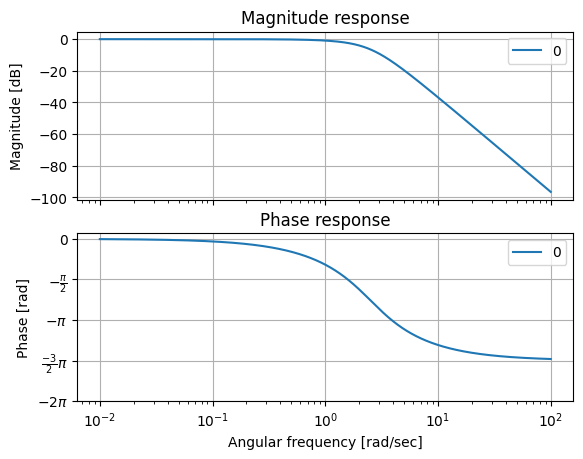

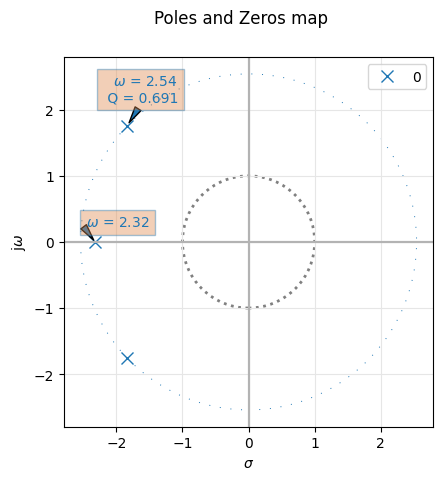

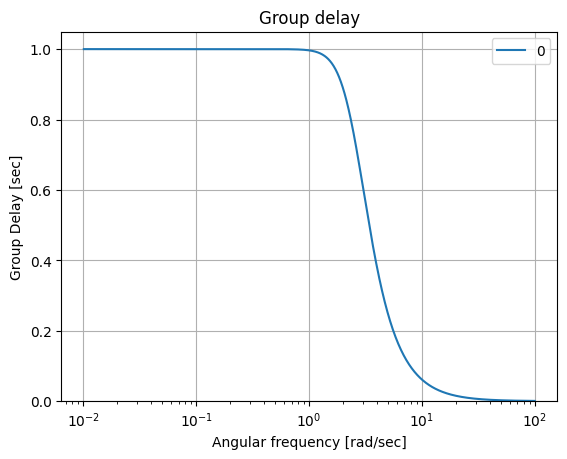

In [6]:
num=[15]
den=[1,6,15,15]
T=sp.TransferFunction(num,den)
analyze_sys(T)

#### 3. Evaluar el retardo de grupo $D(\omega=2.5)$ y expresar en forma porcentual el error o desviamiento respecto a $D(\omega=0)$.

Una de las formas de calcular analíticamente el retardo es a partir de la fase de las singularidades. Dado que la fase de la totalidad de los polos o la totalidad de los ceros es igual a la sumatoria de la fase individual de estos:

$$
\phi_T(\omega) = \sum\limits_{i=1}^{n_Z} \phi_{Z\,i} - \sum\limits_{i=1}^{n_P} \phi_{P\,i},\quad \phi_i = tg^{-1}\left( \frac{\omega \pm \omega_{i}}{\sigma_{i}} \right)
$$

$$
D(\omega) = - \frac{\partial \phi_T}{\partial \omega} \Rightarrow \frac{\partial tg^{-1}(U)}{\partial x} = \frac{1}{1+U^2} \frac{\partial U}{\partial x} \Rightarrow \frac{\partial \phi_i}{\partial \omega} = \frac{\sigma_i}{\sigma_i^2+(\omega \pm \omega_i)^2} 
$$

$$
D(\omega) = - \sum\limits_{i=1}^{n_Z} \frac{\sigma_{Z\,i}}{\sigma_{Z\,i}^2+(\omega \pm \omega_{Z\,i})^2}  + \sum\limits_{i=1}^{n_P} \frac{\sigma_{P\,i}}{\sigma_{P\,i}^2+(\omega \pm \omega_{P\,i})^2} 
$$

La $T(s)$ de orden 3 factorizada en polos y ceros es:

$$ T(s)=\frac{15}{(s+2.322)(s+1.839+j1.754)(s+1.839-j1.754)} \Rightarrow$$

$$
D(\omega) = \frac{2.322}{2.322^2+\omega^2} + \frac{1.839}{1.839^2+(\omega+1.754)^2} + \frac{1.839}{1.839^2+(\omega-1.754)^2}
$$

Primero verificamos que $D(\omega=0)=1$:

$$
D(\omega=0) = \frac{2.322}{2.322^2} + \frac{1.839}{1.839^2+1.754^2} + \frac{1.839}{1.839^2+(-1.754)^2} = 0.4307 + 2\cdot 0.2847 = 1.00015 \approx 1
$$

Ahora, para $D(\omega=2.5)$:

$$
D(\omega=2.5) = \frac{2.322}{2.322^2+2.5^2} + \frac{1.839}{1.839^2+(2.5+1.754)^2} + \frac{1.839}{1.839^2+(2.5-1.754)^2} = 0.1994+0.0856+0.4669 = 0.752
$$

$$
\Rightarrow \left. \frac{D(0)-D(2.5)}{D(0)} \right|_{[\%]}=24,81\%
$$

#### 4. Sintetizar el circuito normalizado con estructuras Sallen-Key con K=1 (real, negativa y unitaria). 

<img src="fig/sallenkey_unit.png"  width="500"/>

Obtenemos la transferencia:

$$
\begin{cases}
V_a(G_1+G_2+sC_2)-V_iG_1-V_o(G_2+sC_2)=0 \\
V_o(G_2+sC_1)-V_a(G_2)=0 \Rightarrow V_a=V_o\frac{G_2+sC_1}{G_2}
\end{cases}
$$

$$
\Rightarrow V_o\left( \frac{G_2+sC_1}{G_2} (G_1+G_2+sC_2) - (G_2+sC_2) \right) = V_i G_1
$$

$$
V_o \frac{G_1G_2 + G_2^2 + sC_2G_2 + sC_1G_1 + sC_1G_2 + s^2C_1C_2 - G_2^2 - sC_2G_2}{G_2 G_1} = V_i
$$

$$
T(s) = \frac{V_o}{V_i} = \frac{G_2 G_1}{s^2C_1C_2 +  sC_1(G_1+G_2) + G_1G_2} = = \frac{\dfrac{G_1G_2}{C_1C_2}}{s^2 + s\dfrac{G_1+G_2}{C_2} + \dfrac{G_1G_2}{C_1C_2}}
$$

$$
\begin{cases}
\omega_0 = \sqrt{\dfrac{G_1G_2}{C_1C_2}} \\
Q = \sqrt{\dfrac{C_2}{C_1}} \dfrac{\sqrt{G_1G_2}}{G_1+G_2}
\end{cases}
$$

Planteo $R_1 = R_2 = \Omega_Z$ y dejo $C_1$ y $C_2$ libres:


$$
\begin{cases}
\omega_0 = \sqrt{\dfrac{1}{C_1C_2}} \\
Q = \dfrac{1}{2}\sqrt{\dfrac{C_2}{C_1}}
\end{cases} \hspace{0.5cm} \Rightarrow \hspace{0.5cm}
\begin{cases}
\omega_0 \cdot Q = \dfrac{1}{2} \sqrt{\dfrac{C_2}{C_1}} \dfrac{1}{\sqrt{C_1C_2}} \Rightarrow C_1 = \dfrac{1}{2 \omega_0 Q} \\
\dfrac{\omega_0}{Q} = 2 \sqrt{\dfrac{C_1}{C_2}} \dfrac{1}{\sqrt{C_1C_2}} \Rightarrow C_2 = \dfrac{2Q}{\omega_0}
\end{cases}
$$

Además hay que incluír una sección de primer orden, por lo que la sintetización resultaría así:

<img src="fig/filtro.png"  width="800"/>

#### 5. Desnormalizar los componentes para obtener un $D(\omega=0)=200\mu s$. Simular numericamente en LTSpice para verificar.

Recordemos que la norma de frecuencia la definimos como $\Omega_{\omega}=\frac{1}{D}$:

$$ \Omega_\omega=\frac{1}{200\mu s} = 5000\frac{\text{rad}}{\text{s}} = 795.77 \text{ Hz} $$

$$
\Rightarrow \begin{cases}
\omega_c = 795.77 \text{ Hz} \\
\omega_s = 1989.44 \text{ Hz}
\end{cases}
$$

Resultaría en:

$$
\begin{cases}
C = \dfrac{1}{2.322\cdot5000\frac{\text{rad}}{\text{s}}} = 86.133 \mu F  \\
C_1 = 56.976 \mu F \\
C_2 = 108.82 \mu F
\end{cases}
$$

A continuación, la simulación del cirucito en _LTSpice_:

<img src="fig/ltspice_circ.png"  width="800"/>

<img src="fig/ltspice_cursor.png" align="right" width="250"/>

<img src="fig/ltspice_graf.png"  width="600"/>

Se colocaron cursores en $\omega_c$ y $\omega_s$, y se puede verificar tanto que el retardo en la banda de paso es de 200$\mu s$, que la atenuación en $\omega_c$ es de menos de 1dB, y que el retardo para $\omega_s$ es aproximadamente un 75% del de banda de paso.